In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pylab as pl

sys.path.append(os.path.join("..", "."))

from package.visualization.plot import plot_shap_distribution

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X = pd.read_pickle("../data/shap/x_values.pkl")
num_patients = 500
X_shapley = X.iloc[:num_patients, :]
shap_values = np.load("../data/shap/shap_values.npy")
shap_interaction_values = np.load("../data/shap/shap_interaction_values.npy")

In [3]:
n_bins = 100

## Distribución con respecto a la suma parcial de las variables

In [4]:
top_variables = [
    "age",
    "sex_isFemale",
    "systolic_blood_pressure",
    "bmi",
    "urine_albumin_isNegative",
    "pulse_pressure",
    "rand"
]

Variable: age


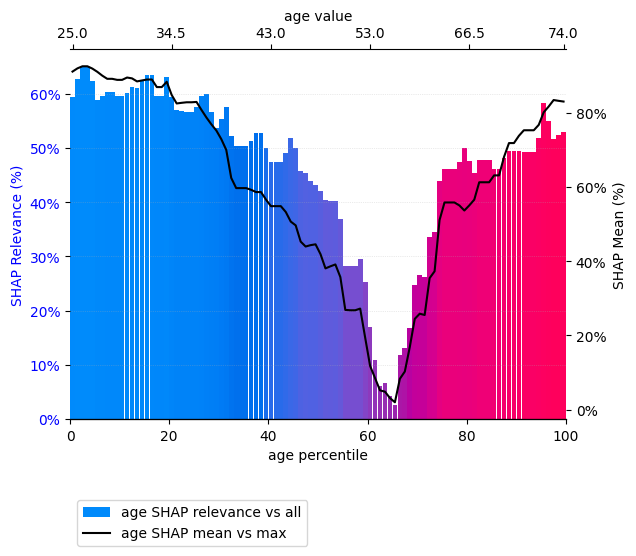

Minimum relevance where age equals 56.170000000000016
Variable: sex_isFemale


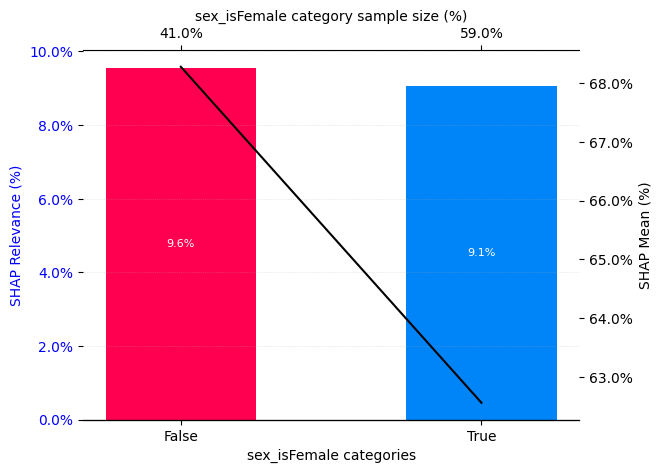

Minimum relevance where sex_isFemale equals 59.0%
Variable: systolic_blood_pressure


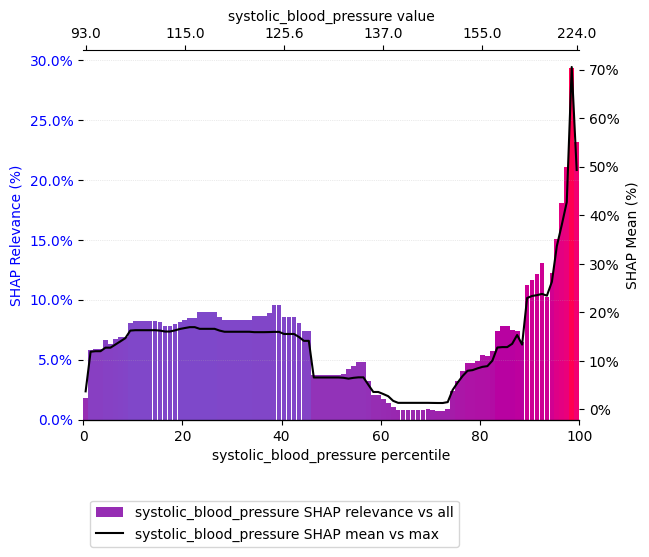

Minimum relevance where systolic_blood_pressure equals 144.0
Variable: bmi


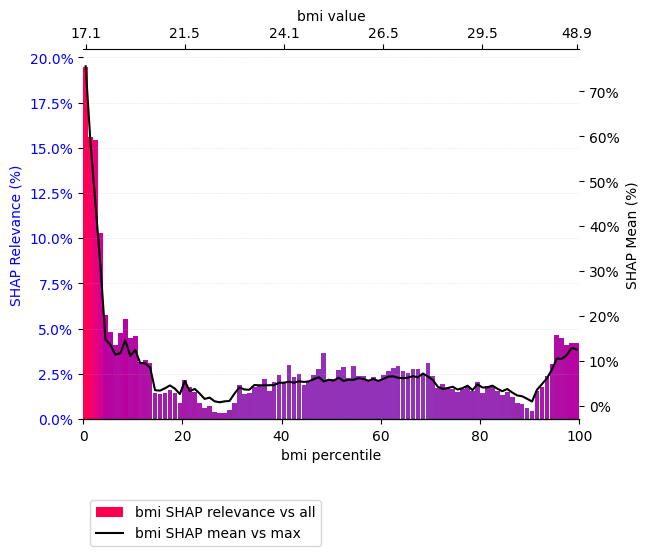

Minimum relevance where bmi equals 22.586886577262828
Variable: urine_albumin_isNegative


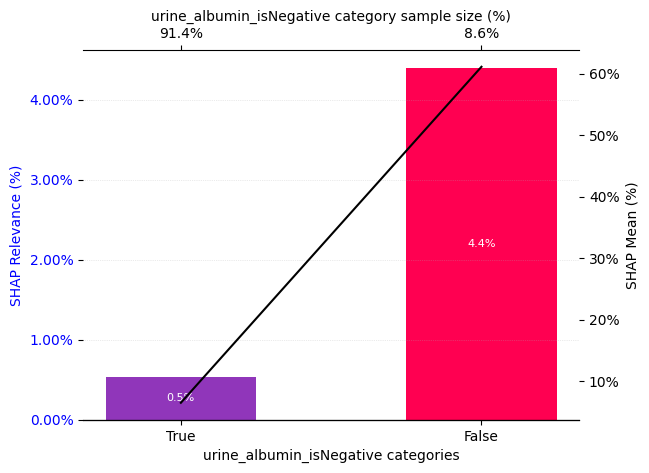

Minimum relevance where urine_albumin_isNegative equals 91.4%
Variable: pulse_pressure


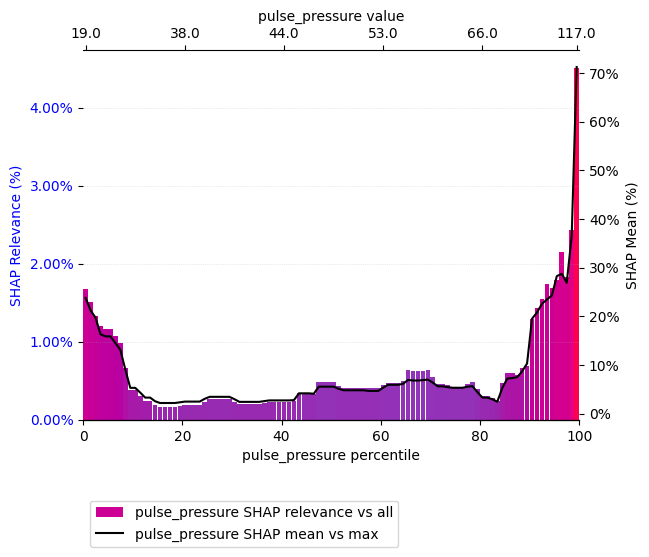

Minimum relevance where pulse_pressure equals 36.0
Variable: rand


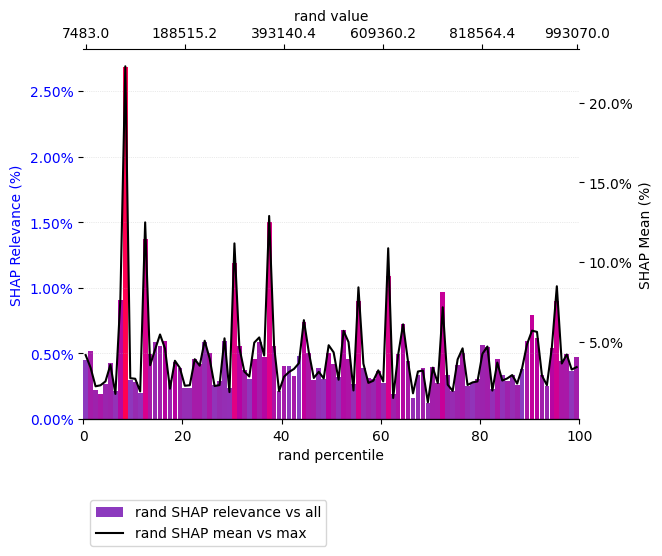

Minimum relevance where rand equals 701011.5665696898


In [5]:
for variable_name in top_variables:
    print(f"Variable: {variable_name}")
    results = plot_shap_distribution(variable_name, X_shapley, shap_values, n_bins)
    min_index = np.argmin(results["abs_shap_relevance"])
    print(f"Minimum relevance where {variable_name} equals {results['variable_label'][min_index]}")